In [17]:
from pathlib import Path

**Loading data**

In [18]:
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

path_pseudo = Path("Data/Comments/Evaluated_pseudo_multilingual.csv")
path_scientific = Path("Data/Comments/Evaluated_scientific_multilingual.csv")

df_pseudo = pd.read_csv(path_pseudo).rename(columns={"etiqueta": "label"})
df_scientific = pd.read_csv(path_scientific).rename(columns={"etiqueta": "label"})

df_pseudo["timestamp"] = pd.to_datetime(df_pseudo["timestamp"], utc=True)
df_scientific["timestamp"] = pd.to_datetime(df_scientific["timestamp"], utc=True)

TOTAL_COMMENTS_PSEUDO = len(df_pseudo)
TOTAL_COMMENTS_SCI = len(df_scientific)
NETWORK_TOTAL_COMMENTS = {
    "pseudo": TOTAL_COMMENTS_PSEUDO,
    "scientific": TOTAL_COMMENTS_SCI,
}

print(f"Pseudo comments loaded: {TOTAL_COMMENTS_PSEUDO:,} from {path_pseudo}")
print(f"Scientific comments loaded: {TOTAL_COMMENTS_SCI:,} from {path_scientific}")

Pseudo comments loaded: 32,025 from Data\Comments\Evaluated_pseudo_multilingual.csv
Scientific comments loaded: 20,386 from Data\Comments\Evaluated_scientific_multilingual.csv


**Merging categories "Insult" and "Desires".**

In [19]:
for df in [df_pseudo, df_scientific]:
    df["label"] = df["label"].replace(
        {
            "Insult": "Emoji-only or \nBrief Acknowledgement",
            "Desires": "Emoji-only or \nBrief Acknowledgement",
        }
    )

**Percentages per category**

In [20]:
pseudo_pct = (df_pseudo["label"]
              .value_counts(normalize=True, dropna=False)
              .mul(100)
              .rename("pct")
              .reset_index()
              .rename(columns={"index": "label"}))

scientific_pct = (df_scientific["label"]
                  .value_counts(normalize=True, dropna=False)
                  .mul(100)
                  .rename("pct")
                  .reset_index()
                  .rename(columns={"index": "label"}))

In [21]:
pseudo_pct

,label,pct
0,Expression of personal feelings,33.133489
1,Comparison,20.911788
2,Compliment,11.313037
3,Thanking,10.379391
4,Emoji-only or \nBrief Acknowledgement,9.686183
5,Greetings,2.579235
6,Advice request,2.579235
7,Speculation,1.427010
8,Joke,0.999219
9,Pseudoscientific treatment,0.933646


In [22]:
scientific_pct

,label,pct
0,Expression of personal feelings,36.662415
1,Comparison,28.249779
2,Compliment,7.907387
3,Advice request,4.817031
4,Medical treatment,4.753262
5,Emoji-only or \nBrief Acknowledgement,3.855587
6,Thanking,3.237516
7,Speculation,1.962131
8,Greetings,1.574610
9,Advice Give,1.108604


**Mapping and translating**

In [23]:
def shorten_and_split_nodes(df, nodes_to_shorten=None, nodes_to_split=None,
                            label_col="label", split_col="emotion"):
    # 1) Renamed labels (for example, remove "personal")
    if nodes_to_shorten:
        df[label_col] = df[label_col].replace(nodes_to_shorten)

    # 2) Split: label -> label + "\n" + emotion
    if nodes_to_split:
        mask = df[label_col].isin(nodes_to_split) & df[split_col].notna()
        df.loc[mask, label_col] = df.loc[mask, label_col] + "\n" + df.loc[mask, split_col].astype(str)

    return df


emotion_translation = {
    "Negativo": "Negative",
    "Positivo": "Positive",
    "Neutral":  "Neutral",
}

# Normalize (optional): handles spaces or NaN values
for df in (df_pseudo, df_scientific):
    df["emotion"] = df["emotion"].astype(str).str.strip().replace({"nan": None})
    df["emotion"] = df["emotion"].replace(emotion_translation)  # or .map(...)


nodes_to_shorten = {"Expression of personal feelings": "Expression of feelings"}
nodes_to_split = ["Expression of feelings", "Comparison"]

df_pseudo = shorten_and_split_nodes(df_pseudo, nodes_to_shorten, nodes_to_split)
df_scientific = shorten_and_split_nodes(df_scientific, nodes_to_shorten, nodes_to_split)

Supplementary node-strength comparison saved to: Data\Results\Networks\Sensitivity\full_network_node_comparison.csv


,Node,Pseudoscientific total strength (%),Scientific total strength (%),Difference in total strength (pp),Pseudoscientific in-strength (%),Scientific in-strength (%),Pseudoscientific out-strength (%),Scientific out-strength (%),Pseudoscientific in-degree,Scientific in-degree,Pseudoscientific out-degree,Scientific out-degree
0,Expression of feelings | Negative,8.32,17.51,-9.19,7.39,15.94,9.26,19.07,28,27,28,27
1,Comparison | Negative,8.05,15.39,-7.34,7.76,15.36,8.33,15.43,26,28,28,27
2,Thanking,9.72,2.98,6.74,9.71,3.20,9.74,2.75,27,23,26,23
3,Expression of feelings | Positive,21.68,15.39,6.29,18.71,15.26,24.65,15.51,28,27,28,28
4,Emoji-only or | Brief Acknowledgement,9.54,3.80,5.74,12.89,4.91,6.19,2.69,28,23,27,25
5,Medical treatment,0.98,4.57,-3.59,0.91,4.38,1.06,4.76,19,21,22,25
6,Compliment,10.73,7.24,3.49,11.26,7.16,10.20,7.33,27,24,28,26
7,Advice request,2.49,4.43,-1.94,1.99,3.66,2.99,5.19,25,24,27,26
8,Comparison | Positive,10.65,8.87,1.78,10.44,8.93,10.86,8.81,28,26,28,25
9,Expression of feelings | Neutral,2.95,4.36,-1.41,2.68,4.65,3.22,4.08,25,27,25,24


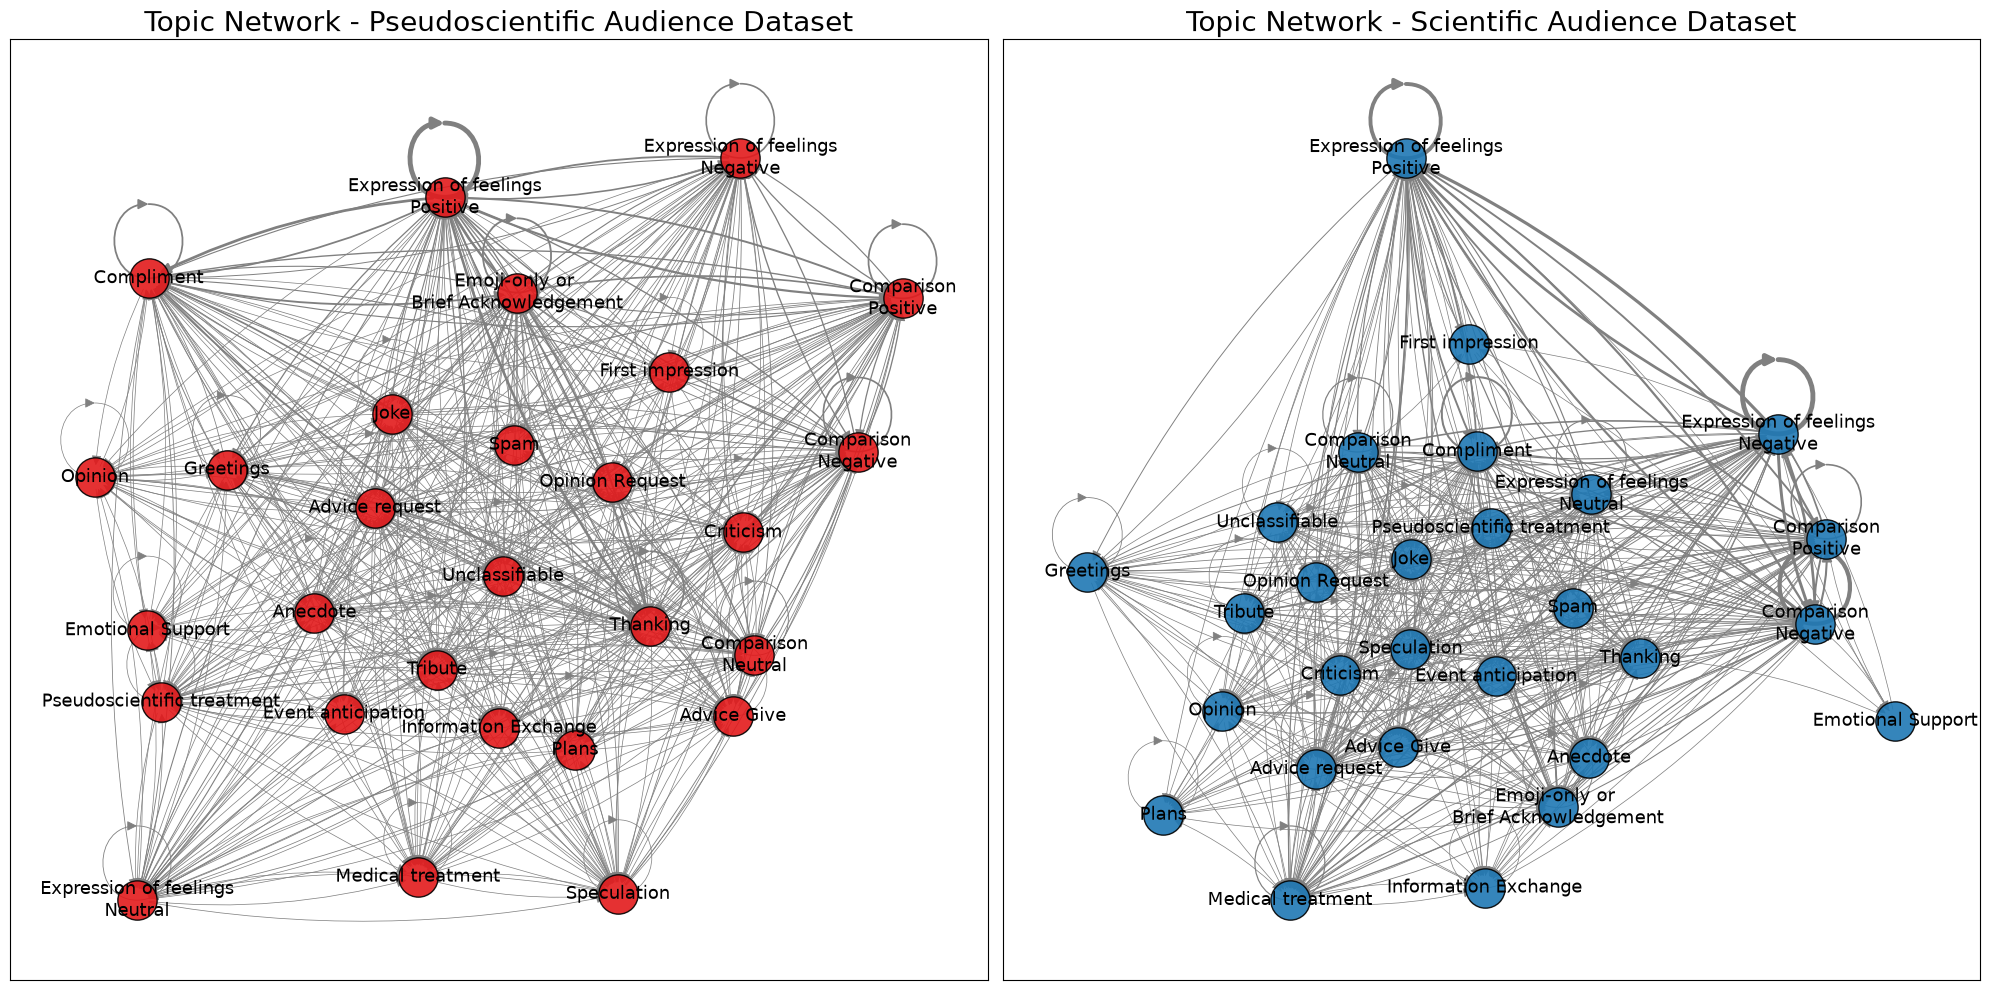

In [24]:

# Function for creating the networks
def create_network(
    df,
    conversation_col="conversation_id",
    state_col="label",
    timestamp_col="timestamp",
):
    """Create a weighted directed transition network within conversations."""
    data = df.sort_values([conversation_col, timestamp_col, "comment_id"]).copy()
    data["next_topic"] = data.groupby(conversation_col)[state_col].shift(-1)
    transitions = data.dropna(subset=["next_topic"])

    G = nx.DiGraph()
    transition_counts = transitions.groupby([state_col, "next_topic"]).size()
    for (source, target), weight in transition_counts.items():
        G.add_edge(source, target, weight=int(weight))

    return G


# Create the networks
G_pseudo = create_network(df_pseudo)
G_scientific = create_network(df_scientific)

from IPython.display import display

FULL_NETWORK_NODE_COMPARISON_FILE = Path("Data/Results/Networks/Sensitivity/full_network_node_comparison.csv")
NETWORK_LABELS = {
    "pseudo": "Pseudoscientific",
    "scientific": "Scientific",
}


def node_label_for_table(value):
    return str(value).replace("\n", " | ")


def full_network_node_metrics(G, network):
    """Calculate full-network node-level weighted strength and directed degree."""
    rows = []
    for node in G.nodes():
        weight_in = int(G.in_degree(node, weight="weight"))
        weight_out = int(G.out_degree(node, weight="weight"))
        rows.append({
            "Network": NETWORK_LABELS.get(network, str(network).title()),
            "Node": node_label_for_table(node),
            "Weight in": weight_in,
            "Weight out": weight_out,
            "Total weight strength": weight_in + weight_out,
            "Degree in": int(G.in_degree(node)),
            "Degree out": int(G.out_degree(node)),
        })

    return pd.DataFrame(rows)


def add_normalized_strength_metrics(metrics_df):
    """Normalize each strength metric by its within-network node-strength sum."""
    metrics_df = metrics_df.copy()
    strength_columns = ["Weight in", "Weight out", "Total weight strength"]
    for column in strength_columns:
        denominator = metrics_df.groupby("Network")[column].transform("sum")
        metrics_df[f"{column} (%)"] = (100 * metrics_df[column] / denominator).round(2)
    return metrics_df


def assert_strength_normalization(metrics_df, tolerance=0.1):
    """Check that rounded normalized strength columns sum to approximately 100%."""
    normalized_columns = ["Weight in (%)", "Weight out (%)", "Total weight strength (%)"]
    for network, network_df in metrics_df.groupby("Network"):
        for column in normalized_columns:
            total = network_df[column].sum()
            if abs(total - 100) > tolerance:
                raise ValueError(
                    f"{column} sums to {total:.2f}% for {network}, expected approximately 100%."
                )


def build_full_network_node_comparison(metrics_df):
    """Create one supplementary row per node with side-by-side relative strength metrics."""
    pseudo = metrics_df.loc[
        metrics_df["Network"] == "Pseudoscientific",
        [
            "Node",
            "Total weight strength (%)",
            "Weight in (%)",
            "Weight out (%)",
            "Degree in",
            "Degree out",
        ],
    ].rename(columns={
        "Total weight strength (%)": "Pseudoscientific total strength (%)",
        "Weight in (%)": "Pseudoscientific in-strength (%)",
        "Weight out (%)": "Pseudoscientific out-strength (%)",
        "Degree in": "Pseudoscientific in-degree",
        "Degree out": "Pseudoscientific out-degree",
    })
    scientific = metrics_df.loc[
        metrics_df["Network"] == "Scientific",
        [
            "Node",
            "Total weight strength (%)",
            "Weight in (%)",
            "Weight out (%)",
            "Degree in",
            "Degree out",
        ],
    ].rename(columns={
        "Total weight strength (%)": "Scientific total strength (%)",
        "Weight in (%)": "Scientific in-strength (%)",
        "Weight out (%)": "Scientific out-strength (%)",
        "Degree in": "Scientific in-degree",
        "Degree out": "Scientific out-degree",
    })

    comparison = pseudo.merge(scientific, on="Node", how="outer").fillna(0)
    degree_columns = [
        "Pseudoscientific in-degree",
        "Scientific in-degree",
        "Pseudoscientific out-degree",
        "Scientific out-degree",
    ]
    comparison[degree_columns] = comparison[degree_columns].astype(int)
    comparison["Difference in total strength (pp)"] = (
        comparison["Pseudoscientific total strength (%)"]
        - comparison["Scientific total strength (%)"]
    ).round(2)
    comparison["_Absolute difference in total strength (pp)"] = comparison[
        "Difference in total strength (pp)"
    ].abs().round(2)

    comparison = comparison[
        [
            "Node",
            "Pseudoscientific total strength (%)",
            "Scientific total strength (%)",
            "Difference in total strength (pp)",
            "Pseudoscientific in-strength (%)",
            "Scientific in-strength (%)",
            "Pseudoscientific out-strength (%)",
            "Scientific out-strength (%)",
            "Pseudoscientific in-degree",
            "Scientific in-degree",
            "Pseudoscientific out-degree",
            "Scientific out-degree",
            "_Absolute difference in total strength (pp)",
        ]
    ]

    return comparison.sort_values(
        ["_Absolute difference in total strength (pp)", "Node"],
        ascending=[False, True],
    ).drop(columns="_Absolute difference in total strength (pp)").reset_index(drop=True)


def assert_comparison_differences(comparison_df):
    """Check signed percentage-point differences and absolute-difference sorting."""
    expected = (
        comparison_df["Pseudoscientific total strength (%)"]
        - comparison_df["Scientific total strength (%)"]
    ).round(2)
    if not comparison_df["Difference in total strength (pp)"].round(2).equals(expected):
        raise ValueError("Difference in total strength (pp) is not pseudoscientific minus scientific.")

    absolute_difference = comparison_df["Difference in total strength (pp)"].abs().round(2)
    if not absolute_difference.is_monotonic_decreasing:
        raise ValueError("Rows are not sorted by absolute total-strength difference.")


full_network_node_metrics_df = pd.concat(
    [
        full_network_node_metrics(G_pseudo, "pseudo"),
        full_network_node_metrics(G_scientific, "scientific"),
    ],
    ignore_index=True,
)
full_network_node_metrics_df = add_normalized_strength_metrics(full_network_node_metrics_df)
assert_strength_normalization(full_network_node_metrics_df)
full_network_node_metrics_df = full_network_node_metrics_df.sort_values(
    ["Network", "Total weight strength", "Weight in", "Node"],
    ascending=[True, False, False, True],
).reset_index(drop=True)

full_network_node_comparison_df = build_full_network_node_comparison(full_network_node_metrics_df)
assert_comparison_differences(full_network_node_comparison_df)

FULL_NETWORK_NODE_COMPARISON_FILE.parent.mkdir(parents=True, exist_ok=True)
full_network_node_comparison_df.to_csv(FULL_NETWORK_NODE_COMPARISON_FILE, index=False)
print(f"Supplementary node-strength comparison saved to: {FULL_NETWORK_NODE_COMPARISON_FILE}")

display(full_network_node_comparison_df)

# Figure configuration
plt.figure(figsize=(20, 10))

# Function for normalizing weights
def normalize_weights(weights, max_width=3, base_width=0.5):
    max_weight = max(weights)
    return [base_width + (w/max_weight)*max_width for w in weights]

# Subplot 1: Pseudoscientific network
plt.subplot(1, 2, 1)
pos1 = nx.kamada_kawai_layout(G_pseudo)
edge_weights_pseudo = [d['weight'] for _, _, d in G_pseudo.edges(data=True)]

nx.draw_networkx_nodes(G_pseudo, pos1,
                      node_size=800,
                      node_color='#e31a1c',
                      edgecolors='black',
                      alpha=0.9)

nx.draw_networkx_edges(G_pseudo, pos1,
                      edge_color='gray',
                      arrows=True,
                      arrowsize=15,
                      width=normalize_weights(edge_weights_pseudo),
                      connectionstyle='arc3,rad=0.1')

nx.draw_networkx_labels(G_pseudo, pos1, font_size=13, font_color='black')
plt.title("Topic Network - Pseudoscientific Audience Dataset", fontsize=20)

# Subplot 2: Scientific network
plt.subplot(1, 2, 2)
pos2 = nx.kamada_kawai_layout(G_scientific)
edge_weights_scientific = [d['weight'] for _, _, d in G_scientific.edges(data=True)]

nx.draw_networkx_nodes(G_scientific, pos2,
                      node_size=800,
                      node_color='#1f78b4',
                      edgecolors='black',
                      alpha=0.9)

nx.draw_networkx_edges(G_scientific, pos2,
                      edge_color='gray',
                      arrows=True,
                      arrowsize=15,
                      width=normalize_weights(edge_weights_scientific),
                      connectionstyle='arc3,rad=0.1')

nx.draw_networkx_labels(G_scientific, pos2, font_size=13, font_color='black')
plt.title("Topic Network - Scientific Audience Dataset", fontsize=20)

# Adjust and save
plt.tight_layout()
plt.savefig("Data/Results/Networks/Sensitivity/grouped_networks_unfiltered_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

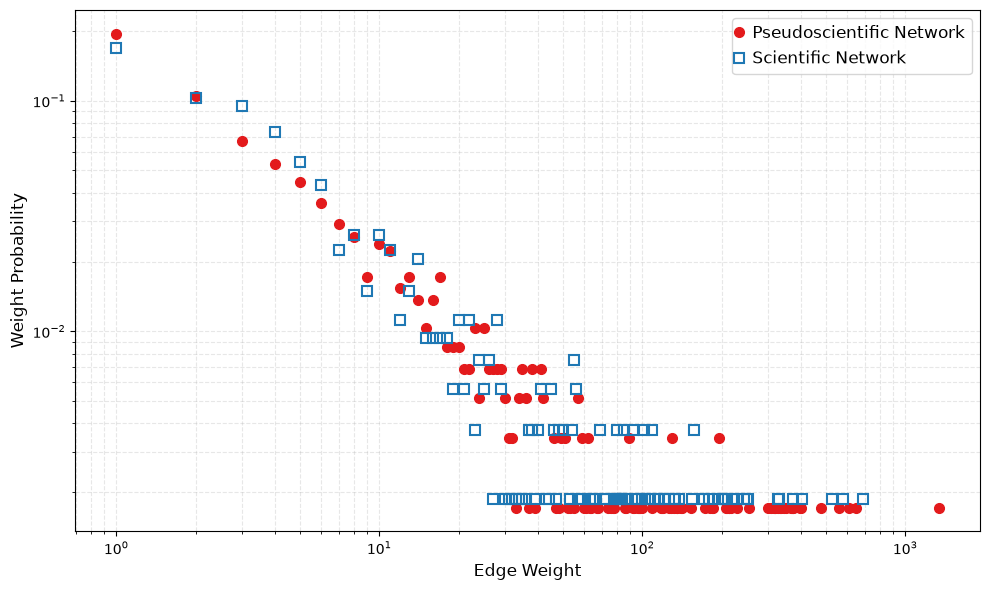

In [26]:
from collections import Counter
import matplotlib.pyplot as plt

# Function to calculate the probabilities of edge weights
def calculate_weight_probabilities(G):
    edge_weights = [G[u][v]['weight'] for u, v in G.edges]
    weight_count = Counter(edge_weights)
    total_edges = len(G.edges)
    return {k: v / total_edges for k, v in weight_count.items()}

# Calculate the weight probabilities for both networks
prob_pseudo = calculate_weight_probabilities(G_pseudo)
prob_scientific = calculate_weight_probabilities(G_scientific)

# Extract data for plotting
weights_pseudo = list(prob_pseudo.keys())
probs_pseudo = list(prob_pseudo.values())

weights_sci = list(prob_scientific.keys())
probs_sci = list(prob_scientific.values())

# Plot configuration
plt.figure(figsize=(10, 6))

# Pseudoscientific Network: red color + solid filled circle
plt.loglog(
    weights_pseudo, probs_pseudo,
    color='#e31a1c',               # Red for the legend and border
    marker='o',                    # Circle
    markersize=7,
    markerfacecolor='#e31a1c',     # Red fill
    linestyle='None',
    label='Pseudoscientific Network'
)

# Scientific Network: blue color + hollow square
plt.loglog(
    weights_sci, probs_sci,
    color='#1f78b4',               # Blue for the legend and border
    marker='s',                    # Square ('s' for square)
    markersize=7,
    markerfacecolor='none',        # 'none' makes the center transparent (hollow)
    markeredgecolor='#1f78b4',     # Force the blue border
    markeredgewidth=1.5,           # Make the square border slightly thicker for visibility
    linestyle='None',
    label='Scientific Network'
)

# Add descriptive elements
plt.xlabel("Edge Weight", fontsize=12)
plt.ylabel("Weight Probability", fontsize=12)

# Adapt the legend: ensure it displays strictly the markers cleanly
plt.legend(fontsize=12, handlelength=0, numpoints=1, scatterpoints=1)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig("Data/Results/Networks/Sensitivity/weight_probabilities.png", dpi=300, bbox_inches='tight')
plt.show()


**Sensitivity analysis: edge-weight threshold**

This section exports a compact edge-threshold table for the complete directed networks. Percentages use each unfiltered network as the denominator.


In [27]:
from pathlib import Path
from IPython.display import display

NETWORK_EDGE_THRESHOLD_OF_INTEREST = 100
NETWORK_EDGE_SELECTED_THRESHOLDS = (50, 75, 100, 150, 200)
NETWORK_EDGE_SENSITIVITY_DIR = Path("Data/Results/Networks/Sensitivity")
NETWORK_EDGE_THRESHOLD_TABLE_FILE = NETWORK_EDGE_SENSITIVITY_DIR / "network_edge_threshold_sensitivity.csv"
NETWORK_LABELS = {
    "pseudo": "Pseudoscientific",
    "scientific": "Scientific",
}


def readable_node_label(value):
    return str(value).replace("\n", " | ")


def top_weight_strength_nodes(retained_edges, top_n=5):
    """Return top node names sorted by weighted in-strength plus out-strength."""
    if not retained_edges:
        return ""

    node_strength = {}
    for source, target, weight in retained_edges:
        node_strength[source] = node_strength.get(source, 0) + weight
        node_strength[target] = node_strength.get(target, 0) + weight

    top_nodes = sorted(
        node_strength.items(),
        key=lambda item: (-item[1], readable_node_label(item[0])),
    )[:top_n]

    return "; ".join(readable_node_label(node) for node, _ in top_nodes)


def edge_threshold_table_for_network(G, network, thresholds=NETWORK_EDGE_SELECTED_THRESHOLDS):
    """Build the compact retained-edge table for one network."""
    edges = [(source, target, int(data["weight"])) for source, target, data in G.edges(data=True)]
    total_edges = len(edges)
    total_weight = sum(weight for _, _, weight in edges)

    rows = []
    for threshold in thresholds:
        retained_edges = [
            (source, target, weight)
            for source, target, weight in edges
            if weight >= threshold
        ]
        retained_weight = sum(weight for _, _, weight in retained_edges)

        rows.append({
            "Network": NETWORK_LABELS.get(network, str(network).title()),
            "Threshold": int(threshold),
            "Edges": len(retained_edges),
            "Percentage of edges": round(100 * len(retained_edges) / total_edges, 2),
            "Percentage of total weight": round(100 * retained_weight / total_weight, 2),
            "Top 5 nodes by weight strength": top_weight_strength_nodes(retained_edges),
        })

    return pd.DataFrame(rows)


def build_network_edge_threshold_table(networks, thresholds=NETWORK_EDGE_SELECTED_THRESHOLDS):
    table = pd.concat(
        [
            edge_threshold_table_for_network(G, network, thresholds=thresholds)
            for network, G in networks.items()
        ],
        ignore_index=True,
    )
    return table.sort_values(["Network", "Threshold"]).reset_index(drop=True)


def run_network_edge_threshold_table(
    networks,
    output_file=NETWORK_EDGE_THRESHOLD_TABLE_FILE,
    thresholds=NETWORK_EDGE_SELECTED_THRESHOLDS,
):
    """Run and export the compact edge-threshold table for both networks."""
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    table = build_network_edge_threshold_table(networks, thresholds=thresholds)
    table.to_csv(output_file, index=False)

    print(f"Edge-threshold table saved to: {output_file}")
    return table


network_edge_selected_thresholds_df = run_network_edge_threshold_table(
    {
        "pseudo": G_pseudo,
        "scientific": G_scientific,
    }
)

display(network_edge_selected_thresholds_df)


Edge-threshold table saved to: Data\Results\Networks\Sensitivity\network_edge_threshold_sensitivity.csv


,Network,Threshold,Edges,Percentage of edges,Percentage of total weight,Top 5 nodes by weight strength
0,Pseudoscientific,50,80,13.72,77.08,Expression of feelings | Positive; Comparison ...
1,Pseudoscientific,75,61,10.46,71.61,Expression of feelings | Positive; Compliment;...
2,Pseudoscientific,100,49,8.40,66.49,Expression of feelings | Positive; Compliment;...
3,Pseudoscientific,150,35,6.00,57.96,Expression of feelings | Positive; Thanking; C...
4,Pseudoscientific,200,28,4.80,51.83,Expression of feelings | Positive; Thanking; C...
5,Scientific,50,74,13.83,72.25,Expression of feelings | Negative; Expression ...
6,Scientific,75,53,9.91,63.73,Expression of feelings | Negative; Expression ...
7,Scientific,100,37,6.92,54.37,Expression of feelings | Negative; Expression ...
8,Scientific,150,22,4.11,42.64,Expression of feelings | Negative; Expression ...
9,Scientific,200,15,2.80,34.52,Expression of feelings | Negative; Comparison ...


**Final network figure export**

This section applies the selected edge-weight threshold once, saves every final network figure, and displays each figure directly in the notebook.

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx
from IPython.display import display

SUBMISSION_FIGURE_DIR = Path("Data/Results/Submission_Figures")
SUBMISSION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

NETWORK_EDGE_THRESHOLD = NETWORK_EDGE_THRESHOLD_OF_INTEREST
MAIN_FIGURE_SIZE = (10, 10)
MAIN_EXPORT_DPI = 100
SUBGRAPH_FIGURE_SIZE = (7, 7)
SUBGRAPH_PANEL_FIGURE_SIZE = (20, 7)
SUBGRAPH_EXPORT_DPI = 300
NODE_SCALE = 17000
EDGE_WIDTH_SCALE = 100
LABEL_FONT_SIZE = 12
LABEL_PAD_POINTS = 4
LABEL_TOP_NODES = 15
LAYOUT_SPACING_FACTOR = 1.4
LAYOUT_ITERATIONS = 100
LAYOUT_SEED = 1
LAYOUT_OUTLIER_PERCENTILE = 0.85
LAYOUT_OUTLIER_RADIUS_FACTOR = 1.15
COLOR_SCHEMES = {
    "pseudo": {"node": "#e31a1c", "edge": "gray"},
    "scientific": {"node": "#1f78b4", "edge": "gray"},
}


def apply_weight_threshold(G, threshold):
    """Return a copy of G with only edges whose weight is at least threshold."""
    G_filtered = G.__class__()
    G_filtered.graph.update(G.graph)
    for u, v, data in G.edges(data=True):
        if data["weight"] >= threshold:
            G_filtered.add_edge(u, v, **data)
    return G_filtered


def percentile(values, q):
    """Small percentile helper to avoid adding another dependency in this notebook cell."""
    values = sorted(values)
    idx = (len(values) - 1) * q
    lo = int(idx)
    hi = min(lo + 1, len(values) - 1)
    frac = idx - lo
    return values[lo] * (1 - frac) + values[hi] * frac


def compact_layout_outliers(
    G,
    pos,
    outlier_percentile=LAYOUT_OUTLIER_PERCENTILE,
    radius_factor=LAYOUT_OUTLIER_RADIUS_FACTOR,
):
    """Pull runaway peripheral nodes back toward the main network radius."""
    if not pos:
        return pos

    components = (
        list(nx.weakly_connected_components(G))
        if G.is_directed()
        else list(nx.connected_components(G))
    )
    main_component = max(components, key=len)
    main_nodes = [node for node in main_component if node in pos]

    center_x = sum(pos[node][0] for node in main_nodes) / len(main_nodes)
    center_y = sum(pos[node][1] for node in main_nodes) / len(main_nodes)
    distances = {
        node: ((pos[node][0] - center_x) ** 2 + (pos[node][1] - center_y) ** 2) ** 0.5
        for node in pos
    }

    reference_distances = [distances[node] for node in main_nodes]
    cap_radius = percentile(reference_distances, outlier_percentile) * radius_factor
    compacted_pos = {}
    for node, xy in pos.items():
        dx = xy[0] - center_x
        dy = xy[1] - center_y
        distance = distances[node]
        if distance > cap_radius:
            scale = cap_radius / distance
            compacted_pos[node] = (center_x + dx * scale, center_y + dy * scale)
        else:
            compacted_pos[node] = (xy[0], xy[1])
    return compacted_pos


def calculate_spaced_layout(G):
    """Calculate a shared layout with stronger node repulsion."""
    node_count = G.number_of_nodes()
    k = LAYOUT_SPACING_FACTOR / (node_count ** 0.5)
    pos = nx.spring_layout(
        G,
        k=k,
        iterations=LAYOUT_ITERATIONS,
        seed=LAYOUT_SEED,
        weight=None,
    )
    return compact_layout_outliers(G, pos)


def set_network_limits(ax, pos, padding=0.08):
    """Add stable label margins without over-compressing the graph."""
    if not pos:
        return
    xs = [xy[0] for xy in pos.values()]
    ys = [xy[1] for xy in pos.values()]
    x_span = max(xs) - min(xs) or 1
    y_span = max(ys) - min(ys) or 1
    ax.set_xlim(min(xs) - x_span * padding, max(xs) + x_span * padding)
    ax.set_ylim(min(ys) - y_span * padding, max(ys) + y_span * padding)


def plot_filtered_network(G, total_comments, ax, color_scheme, fixed_pos, title=""):
    """Draw a threshold-filtered network."""
    graph_pos = {node: fixed_pos[node] for node in G.nodes()}
    weighted_in_degrees = {
        node: weight / total_comments
        for node, weight in dict(G.in_degree(weight="weight")).items()
    }
    node_sizes = {node: weighted_in_degrees[node] * NODE_SCALE for node in graph_pos}

    nx.draw_networkx_nodes(
        G,
        graph_pos,
        nodelist=list(graph_pos),
        node_size=[node_sizes[node] for node in graph_pos],
        node_color=color_scheme["node"],
        edgecolors="black",
        linewidths=2.0,
        alpha=0.9,
        ax=ax,
    )

    self_loops = [(u, v) for u, v in G.edges() if u == v]
    regular_edges = [(u, v) for u, v in G.edges() if u != v]
    width_regular = [G[u][v]["weight"] / total_comments * EDGE_WIDTH_SCALE for u, v in regular_edges]
    width_loops = [G[u][v]["weight"] / total_comments * EDGE_WIDTH_SCALE for u, v in self_loops]

    nx.draw_networkx_edges(
        G,
        graph_pos,
        edgelist=regular_edges,
        edge_color=color_scheme["edge"],
        arrows=True,
        arrowsize=22,
        width=width_regular,
        connectionstyle="arc3,rad=0.1",
        alpha=0.6,
        ax=ax,
    )
    nx.draw_networkx_edges(
        G,
        graph_pos,
        edgelist=self_loops,
        edge_color=color_scheme["edge"],
        arrows=True,
        arrowsize=18,
        width=width_loops,
        connectionstyle="arc3,rad=0.2",
        alpha=0.3,
        ax=ax,
    )

    top_nodes = sorted(weighted_in_degrees.items(), key=lambda x: x[1], reverse=True)[:LABEL_TOP_NODES]
    for node, _ in top_nodes:
        x, y = graph_pos[node]
        node_radius_points = node_sizes[node] ** 0.5 / 2
        label_pad_points = node_radius_points + LABEL_PAD_POINTS
        text = ax.annotate(
            str(node),
            xy=(x, y),
            xytext=(0, -label_pad_points),
            textcoords="offset points",
            fontsize=LABEL_FONT_SIZE,
            fontweight="bold",
            horizontalalignment="center",
            verticalalignment="top",
            zorder=20,
        )
        text.set_clip_on(False)
        text.set_path_effects([pe.withStroke(linewidth=3, foreground="white", alpha=0.9), pe.Normal()])

    ax.set_title(title, fontsize=24, fontweight="bold", y=0.95, pad=2)
    ax.axis("off")
    set_network_limits(ax, graph_pos)


def plot_key_node_subgraph(
    G,
    key_nodes,
    total_comments,
    ax,
    color_scheme,
    fixed_pos,
    title="",
    *,
    radius=1,
    top_n_labels=15,
    node_scale=25000,
    edge_scale=140,
    label_pad_points=4,
    key_node_boost=1.35,
):
    """Draw the ego-subgraph around selected node labels."""
    key_nodes = set(key_nodes)
    missing_nodes = sorted(key_nodes - set(G.nodes()))
    if missing_nodes:
        raise ValueError(f"Key node(s) missing after threshold filtering: {missing_nodes}")

    G_und = G.to_undirected(as_view=True)
    nodes = set()
    for key_node in key_nodes:
        nodes.update(nx.ego_graph(G_und, key_node, radius=radius).nodes())

    H = G.subgraph(nodes).copy()
    pos = {node: fixed_pos[node] for node in H.nodes()}
    weighted_in_degrees = {
        node: H.in_degree(node, weight="weight") / total_comments
        for node in H.nodes()
    }
    node_sizes = {
        node: weighted_in_degrees[node] * node_scale * (key_node_boost if node in key_nodes else 1)
        for node in H.nodes()
    }

    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=list(H.nodes()),
        node_size=[node_sizes[node] for node in H.nodes()],
        node_color=color_scheme["node"],
        edgecolors="black",
        linewidths=2.0,
        alpha=0.9,
        ax=ax,
    )

    self_loops = [(u, v) for u, v in H.edges() if u == v]
    regular_edges = [(u, v) for u, v in H.edges() if u != v]
    width_regular = [H[u][v]["weight"] / total_comments * edge_scale for u, v in regular_edges]
    width_loops = [H[u][v]["weight"] / total_comments * edge_scale for u, v in self_loops]

    nx.draw_networkx_edges(
        H,
        pos,
        edgelist=regular_edges,
        edge_color=color_scheme["edge"],
        arrows=True,
        arrowsize=25,
        width=width_regular,
        connectionstyle="arc3,rad=0.1",
        alpha=0.6,
        ax=ax,
    )
    nx.draw_networkx_edges(
        H,
        pos,
        edgelist=self_loops,
        edge_color=color_scheme["edge"],
        arrows=True,
        arrowsize=20,
        width=width_loops,
        connectionstyle="arc3,rad=0.2",
        alpha=0.3,
        ax=ax,
    )

    top_nodes = sorted(weighted_in_degrees.items(), key=lambda x: x[1], reverse=True)[:top_n_labels]
    for node, _ in top_nodes:
        x, y = pos[node]
        node_radius_points = node_sizes[node] ** 0.5 / 2
        total_label_pad = node_radius_points + label_pad_points
        text = ax.annotate(
            str(node),
            xy=(x, y),
            xytext=(0, -total_label_pad),
            textcoords="offset points",
            fontsize=16,
            fontweight="bold",
            horizontalalignment="center",
            verticalalignment="top",
            zorder=20,
        )
        text.set_path_effects([
            pe.withStroke(linewidth=4, foreground="white", alpha=0.9),
            pe.Normal(),
        ])
        text.set_clip_on(False)

    ax.set_title(title, fontsize=28, fontweight="bold", y=0.93, pad=2)
    ax.axis("off")
    set_network_limits(ax, pos, padding=0.08)
    return H


def save_and_display(fig, file_path, *, dpi, **savefig_kwargs):
    """Save a matplotlib figure and display the same figure in the notebook output."""
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(file_path, dpi=dpi, bbox_inches="tight", **savefig_kwargs)
    display(fig)
    plt.close(fig)
    print(f"Saved: {file_path}")
    return file_path

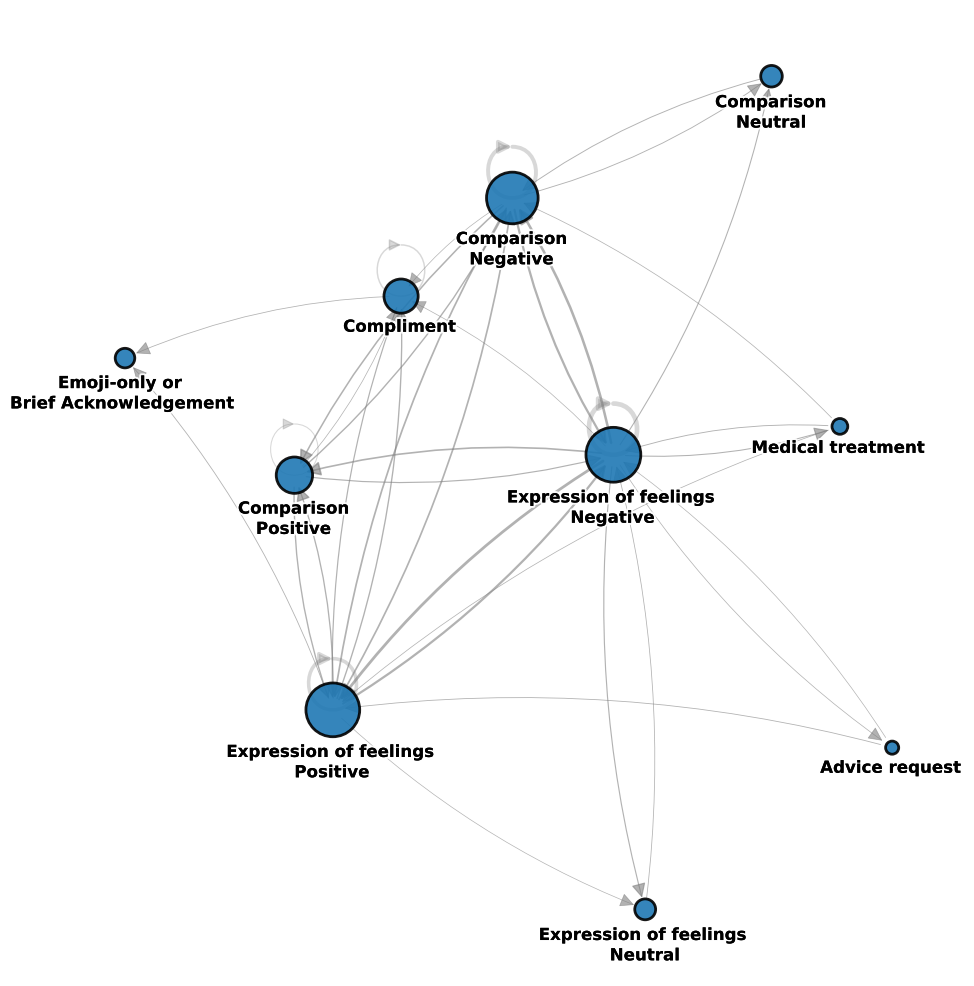

Saved: Data\Results\Submission_Figures\Figure_1_Scientific.png


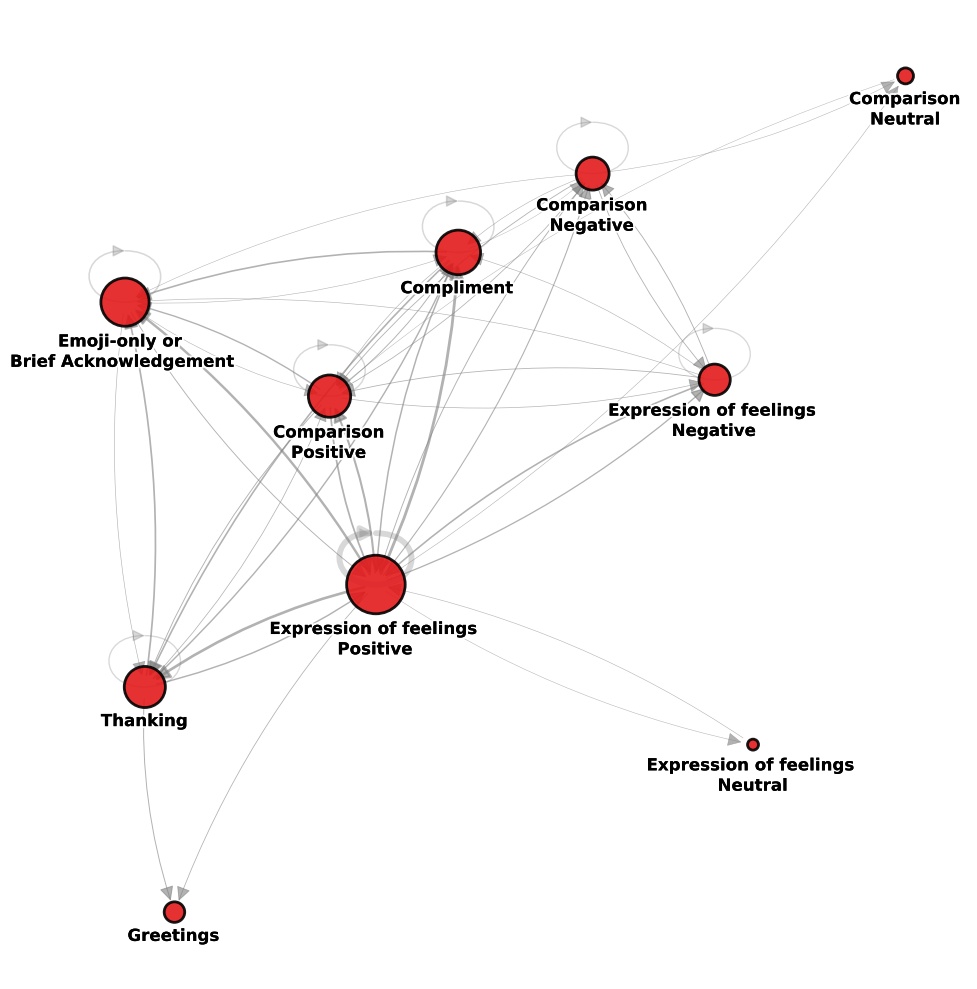

Saved: Data\Results\Submission_Figures\Figure_2_Pseudoscientific.png


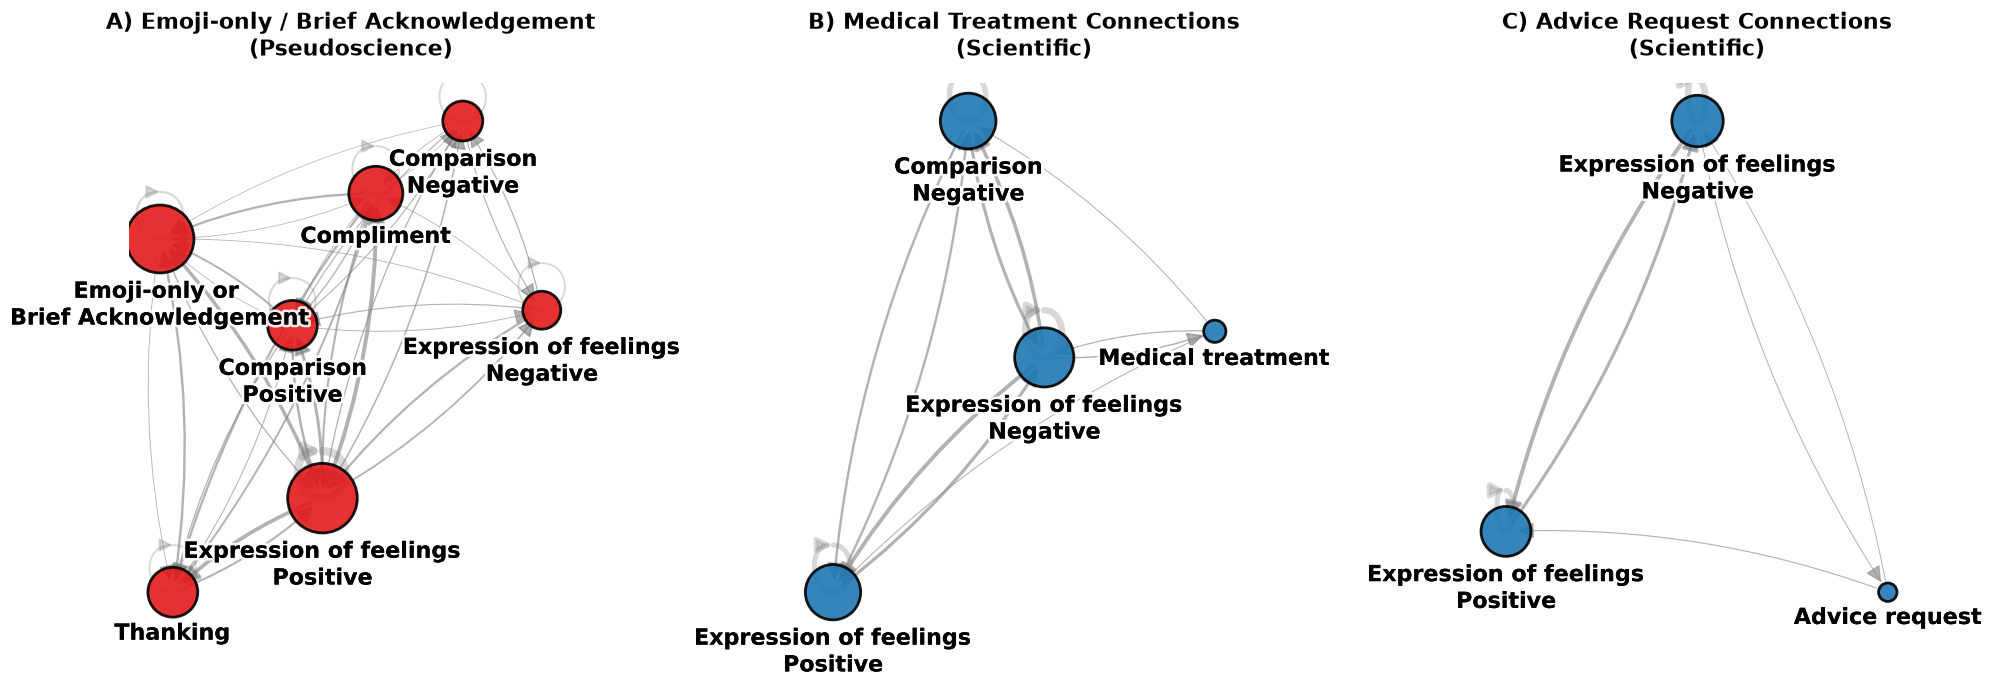

Saved: Data\Results\Submission_Figures\supp_figure6_3subgraphs.png


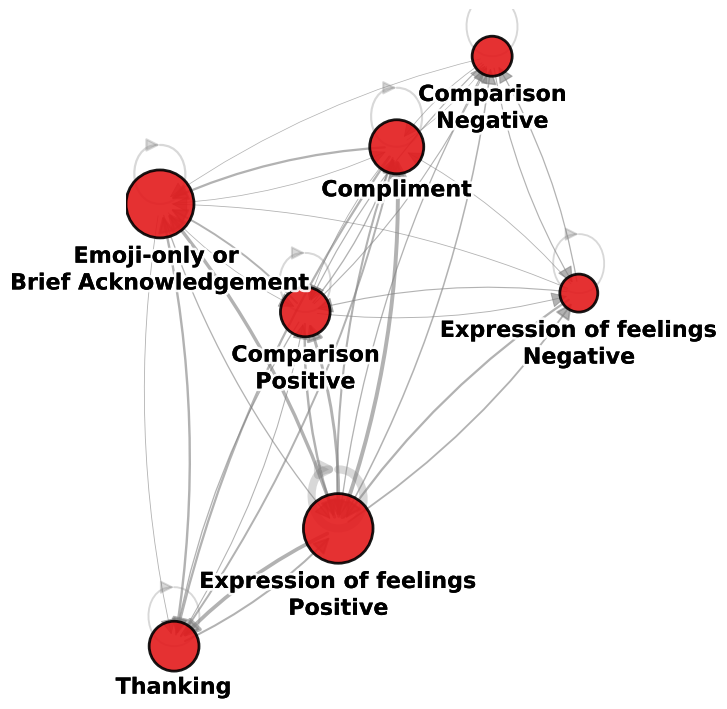

Saved: Data\Results\Submission_Figures\supp_desires_pseudo.png


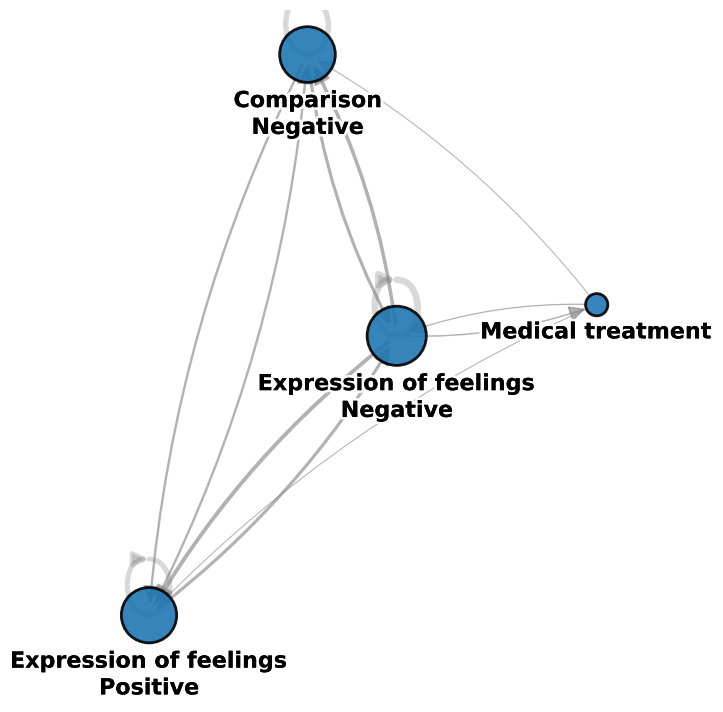

Saved: Data\Results\Submission_Figures\supp_medical_sci.png


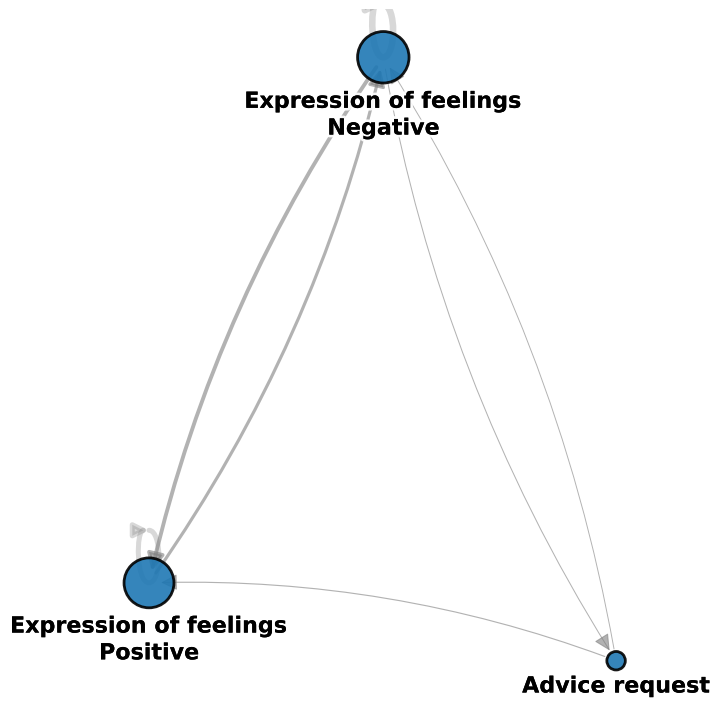

Saved: Data\Results\Submission_Figures\supp_advice_sci.png


In [29]:
G_pseudo_final = apply_weight_threshold(G_pseudo, NETWORK_EDGE_THRESHOLD)
G_scientific_final = apply_weight_threshold(G_scientific, NETWORK_EDGE_THRESHOLD)
G_combined_final = nx.compose(G_scientific_final, G_pseudo_final)
pos_unified = calculate_spaced_layout(G_combined_final)

main_figure_specs = [
    {
        "graph": G_scientific_final,
        "total_comments": TOTAL_COMMENTS_SCI,
        "color_scheme": COLOR_SCHEMES["scientific"],
        "file_path": SUBMISSION_FIGURE_DIR / "Figure_1_Scientific.png",
    },
    {
        "graph": G_pseudo_final,
        "total_comments": TOTAL_COMMENTS_PSEUDO,
        "color_scheme": COLOR_SCHEMES["pseudo"],
        "file_path": SUBMISSION_FIGURE_DIR / "Figure_2_Pseudoscientific.png",
    },
]

for spec in main_figure_specs:
    fig, ax = plt.subplots(figsize=MAIN_FIGURE_SIZE)
    plot_filtered_network(
        spec["graph"],
        spec["total_comments"],
        ax,
        spec["color_scheme"],
        pos_unified,
    )
    fig.tight_layout()
    save_and_display(
        fig,
        spec["file_path"],
        dpi=MAIN_EXPORT_DPI,
        pad_inches=0.06,
    )

subgraph_specs = [
    {
        "key_nodes": ["Emoji-only or \nBrief Acknowledgement"],
        "graph": G_pseudo_final,
        "total_comments": TOTAL_COMMENTS_PSEUDO,
        "color_scheme": COLOR_SCHEMES["pseudo"],
        "panel_title": "A) Emoji-only / Brief Acknowledgement\n(Pseudoscience)",
        "file_path": SUBMISSION_FIGURE_DIR / "supp_desires_pseudo.png",
    },
    {
        "key_nodes": ["Medical treatment"],
        "graph": G_scientific_final,
        "total_comments": TOTAL_COMMENTS_SCI,
        "color_scheme": COLOR_SCHEMES["scientific"],
        "panel_title": "B) Medical Treatment Connections\n(Scientific)",
        "file_path": SUBMISSION_FIGURE_DIR / "supp_medical_sci.png",
    },
    {
        "key_nodes": ["Advice request"],
        "graph": G_scientific_final,
        "total_comments": TOTAL_COMMENTS_SCI,
        "color_scheme": COLOR_SCHEMES["scientific"],
        "panel_title": "C) Advice Request Connections\n(Scientific)",
        "file_path": SUBMISSION_FIGURE_DIR / "supp_advice_sci.png",
    },
]

fig, axes = plt.subplots(1, len(subgraph_specs), figsize=SUBGRAPH_PANEL_FIGURE_SIZE)
for ax, spec in zip(axes, subgraph_specs):
    plot_key_node_subgraph(
        spec["graph"],
        spec["key_nodes"],
        spec["total_comments"],
        ax,
        spec["color_scheme"],
        pos_unified,
    )
    ax.set_title(spec["panel_title"], fontsize=16, fontweight="bold", pad=20)
fig.tight_layout()
save_and_display(
    fig,
    SUBMISSION_FIGURE_DIR / "supp_figure6_3subgraphs.png",
    dpi=SUBGRAPH_EXPORT_DPI,
    pad_inches=0.06,
)

for spec in subgraph_specs:
    fig, ax = plt.subplots(figsize=SUBGRAPH_FIGURE_SIZE)
    plot_key_node_subgraph(
        spec["graph"],
        spec["key_nodes"],
        spec["total_comments"],
        ax,
        spec["color_scheme"],
        pos_unified,
    )
    fig.tight_layout(pad=0)
    save_and_display(
        fig,
        spec["file_path"],
        dpi=SUBGRAPH_EXPORT_DPI,
        pad_inches=0.06,
        facecolor="white",
    )

**Leave-one-source-out boxplots**

This final section checks how much each transition probability changes when one search source is excluded. It reuses the prepared dataframes and the `create_network()` function above. The only output saved here is the boxplot image.

In [30]:
from matplotlib.lines import Line2D

LEAVE_ONE_OUT_FIGURE_PATH = Path("Data/Results/Networks/Sensitivity/leave_one_source_out_boxplots.png")
HIGH_COUNT_CUTOFF = 100

SOURCE_LABELS = {
    "Acupuntura": "Acupuncture",
    "Flores de Bach": "Bach flower remedies",
    "Magnetoterapia": "Magnetotherapy",
    "Naturopatía": "Naturopathy",
    "Reiki": "Reiki",
    "Terapia energética": "Energy therapy",
    "pseudoscientific": "Pseudoscientific camouflage",
    "Fisioterapia deportiva": "Sports physiotherapy",
    "Neurorrehabilitación": "Neurorehabilitation",
    "Procedimiento endóscopico": "Endoscopic procedure",
    "Rehabilitación cardíaca": "Cardiac rehabilitation",
    "Terapia Cognitivo Conductual": "Cognitive behavioral therapy",
    "Tratamiento cáncer": "Cancer treatment",
}

source_lookup_rows = []
for terms_dir in [Path("Data/Videos/terms_pseudo"), Path("Data/Videos/terms_cient")]:
    for file_path in sorted(terms_dir.glob("*.csv")):
        terms = pd.read_csv(file_path)
        source_lookup_rows.append(pd.DataFrame({
            "source": file_path.stem.split("_", 1)[1],
            "case_id": terms.iloc[:, 0],
        }))

source_lookup = (
    pd.concat(source_lookup_rows, ignore_index=True)
    .dropna()
    .drop_duplicates(subset="case_id")
)

df_pseudo_with_source = df_pseudo.merge(source_lookup, on="case_id", how="left")
df_scientific_with_source = df_scientific.merge(source_lookup, on="case_id", how="left")


In [31]:
import numpy as np
def transition_probability_matrix(G, nodes):
    G = G.copy()
    G.add_nodes_from(nodes)

    counts = nx.to_pandas_adjacency(
        G,
        nodelist=nodes,
        weight="weight",
        dtype=float,
    )
    row_totals = counts.sum(axis=1).replace(0, np.nan)
    probabilities = counts.div(row_totals, axis=0).fillna(0)
    return probabilities, counts


def leave_one_source_out_transition_comparison(df, nodes):
    baseline_probabilities, baseline_counts = transition_probability_matrix(
        create_network(df),
        nodes,
    )

    comparison = (
        pd.DataFrame({
            "baseline_probability": baseline_probabilities.stack(),
            "total_transitions": baseline_counts.stack(),
        })
        .rename_axis(index=["source_node", "target_node"])
        .reset_index()
    )
    comparison.insert(
        0,
        "transition",
        comparison["source_node"].astype(str)
        + " → "
        + comparison["target_node"].astype(str),
    )
    comparison = comparison.loc[comparison["total_transitions"] > 0].copy()
    comparison["total_transitions"] = comparison["total_transitions"].astype(int)

    for excluded_source in sorted(df["source"].dropna().unique()):
        subset = df.loc[df["source"] != excluded_source]
        subset_probabilities, _ = transition_probability_matrix(
            create_network(subset),
            nodes,
        )
        comparison[f"without_{excluded_source}"] = [
            subset_probabilities.loc[row.source_node, row.target_node]
            for row in comparison.itertuples(index=False)
        ]

    return comparison.reset_index(drop=True)


all_network_nodes = sorted(set(df_pseudo["label"]) | set(df_scientific["label"]))
pseudo_leave_one_out = leave_one_source_out_transition_comparison(
    df_pseudo_with_source,
    all_network_nodes,
)
scientific_leave_one_out = leave_one_source_out_transition_comparison(
    df_scientific_with_source,
    all_network_nodes,
)


In [32]:
boxplot_rows = []
leave_one_out_tables = {
    "Pseudoscientific network": pseudo_leave_one_out,
    "Scientific network": scientific_leave_one_out,
}

for network, comparison in leave_one_out_tables.items():
    without_columns = [column for column in comparison.columns if column.startswith("without_")]

    for column in without_columns:
        source = column.removeprefix("without_")
        rows = comparison[[
            "transition",
            "total_transitions",
            "baseline_probability",
            column,
        ]].copy()
        rows["network"] = network
        rows["excluded_source"] = SOURCE_LABELS.get(source, source)
        rows["absolute_change_pp"] = (rows[column] - rows["baseline_probability"]).abs() * 100
        rows["transition_count_group"] = np.where(
            rows["total_transitions"] >= HIGH_COUNT_CUTOFF,
            f">= {HIGH_COUNT_CUTOFF} baseline transitions",
            f"< {HIGH_COUNT_CUTOFF} baseline transitions",
        )
        boxplot_rows.append(rows)

leave_one_out_boxplot_data = pd.concat(boxplot_rows, ignore_index=True)


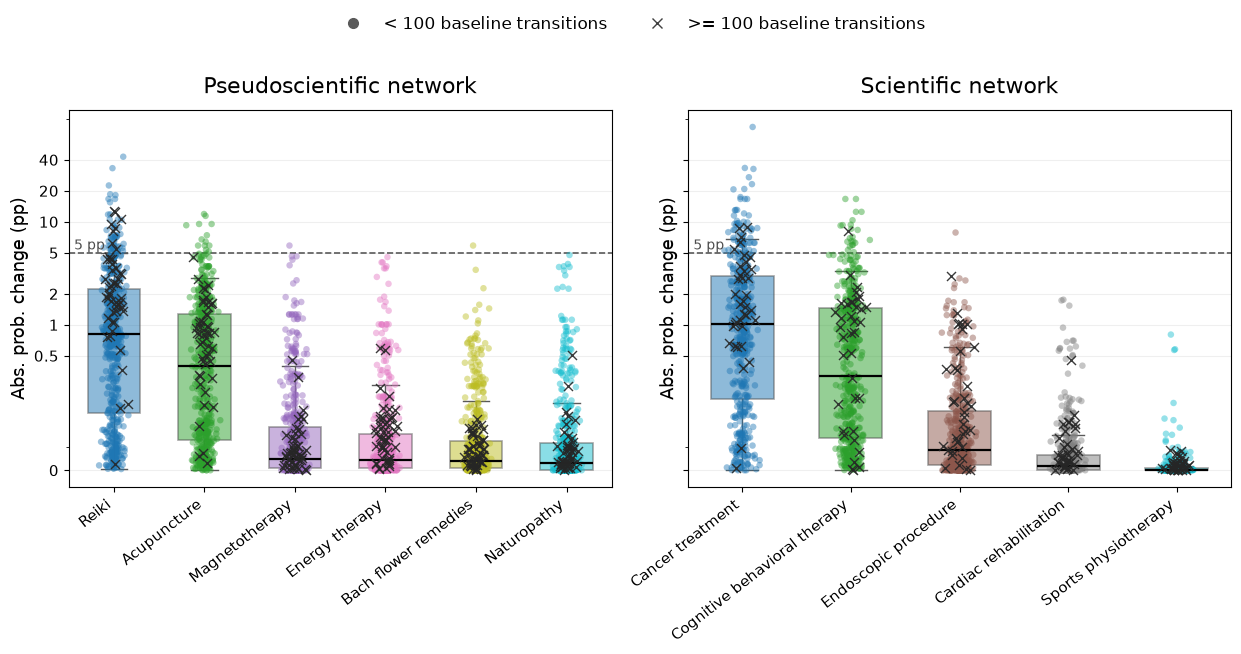

Leave-one-source-out boxplot saved to: Data\Results\Networks\Sensitivity\leave_one_source_out_boxplots.png


In [34]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np


def draw_leave_one_out_panel(ax, data, title):

    # Keep categories ordered by median absolute change
    order = (
        data.groupby("excluded_source")["absolute_change_pp"]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    positions = np.arange(1, len(order) + 1)

    box_values = [
        data.loc[
            data["excluded_source"] == source,
            "absolute_change_pp"
        ].to_numpy()
        for source in order
    ]

    # One colour per excluded source
    colors = plt.cm.tab10(np.linspace(0, 1, len(order)))

    # ---------------------------------------------------------
    # BOXPLOTS
    # ---------------------------------------------------------
    boxplot = ax.boxplot(
        box_values,
        positions=positions,
        widths=0.58,
        patch_artist=True,
        showfliers=False,
        medianprops={
            "color": "black",
            "linewidth": 1.6,
        },
        boxprops={
            "linewidth": 1.2,
            "color": "0.30",
        },
        whiskerprops={
            "linewidth": 1.0,
            "color": "0.35",
        },
        capprops={
            "linewidth": 1.0,
            "color": "0.35",
        },
    )

    for box, color in zip(boxplot["boxes"], colors):
        box.set_facecolor(color)
        box.set_alpha(0.50)

    # ---------------------------------------------------------
    # INDIVIDUAL TRANSITIONS
    # ---------------------------------------------------------
    low_count_label = f"< {HIGH_COUNT_CUTOFF} baseline transitions"
    high_count_label = f">= {HIGH_COUNT_CUTOFF} baseline transitions"

    rng = np.random.default_rng(42)

    for position, source, color in zip(positions, order, colors):

        source_data = data.loc[
            data["excluded_source"] == source
        ].copy()

        # Slight horizontal jitter
        source_data["x"] = (
            position
            + rng.normal(
                0,
                0.055,
                size=len(source_data)
            )
        )

        low_count = source_data.loc[
            source_data["transition_count_group"]
            == low_count_label
        ]

        high_count = source_data.loc[
            source_data["transition_count_group"]
            == high_count_label
        ]

        # Low-count transitions: coloured dots
        ax.scatter(
            low_count["x"],
            low_count["absolute_change_pp"],
            marker="o",
            s=22,
            alpha=0.45,
            color=color,
            edgecolors="none",
            zorder=2,
        )

        # High-count transitions: black crosses
        ax.scatter(
            high_count["x"],
            high_count["absolute_change_pp"],
            marker="x",
            s=42,
            alpha=0.90,
            color="0.15",
            linewidths=1.0,
            zorder=3,
        )

    # ---------------------------------------------------------
    # 5 percentage-point reference
    # ---------------------------------------------------------
    ax.axhline(
        5,
        color="0.35",
        linestyle="--",
        linewidth=1.2,
        zorder=1,
    )

    ax.text(
        0.01,
        5,
        "5 pp",
        transform=ax.get_yaxis_transform(),
        va="bottom",
        ha="left",
        fontsize=10,
        color="0.30",
    )

    # ---------------------------------------------------------
    # AXIS STYLE
    #
    # symlog reproduces the visual behaviour of the second plot:
    # it can include zero while compressing large values.
    # ---------------------------------------------------------
    ax.set_yscale(
        "symlog",
        linthresh=0.5,
        linscale=1.0,
        base=10,
    )

    ax.set_yticks([
        0,
        0.5,
        1,
        2,
        5,
        10,
        20,
        40,
    ])

    ax.set_yticklabels([
        "0",
        "0.5",
        "1",
        "2",
        "5",
        "10",
        "20",
        "40",
    ])

    ax.set_title(
        title,
        fontsize=16,
        pad=12,
    )

    ax.set_ylabel(
        "Abs. prob. change (pp)",
        fontsize=13,
    )

    ax.set_xticks(positions)

    ax.set_xticklabels(
        order,
        rotation=38,
        ha="right",
        fontsize=11,
    )

    ax.tick_params(
        axis="y",
        labelsize=11,
    )

    ax.grid(
        axis="y",
        alpha=0.20,
        linewidth=0.8,
    )

    ax.set_axisbelow(True)


# =============================================================
# FIGURE
# =============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6.4),
    sharey=True,
)

for ax, network in zip(
    axes,
    leave_one_out_tables
):

    draw_leave_one_out_panel(
        ax,
        leave_one_out_boxplot_data.loc[
            leave_one_out_boxplot_data["network"]
            == network
        ],
        network,
    )


# =============================================================
# SHARED LEGEND
# =============================================================

low_count_label = (
    f"< {HIGH_COUNT_CUTOFF} baseline transitions"
)

high_count_label = (
    f">= {HIGH_COUNT_CUTOFF} baseline transitions"
)

fig.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="0.35",
            linestyle="",
            markersize=7,
            label=low_count_label,
        ),
        Line2D(
            [0],
            [0],
            marker="x",
            color="0.25",
            linestyle="",
            markersize=7,
            label=high_count_label,
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=12,
)

fig.subplots_adjust(
    top=0.84,
    bottom=0.25,
    wspace=0.14,
)

LEAVE_ONE_OUT_FIGURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    LEAVE_ONE_OUT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Leave-one-source-out boxplot saved to: "
    f"{LEAVE_ONE_OUT_FIGURE_PATH}"
)